# CoraML Facial-Walk Experiment

Train the transformer on facial walks, generate synthetic walks, reconstruct a graph, and compare link-prediction and graph statistics against the true CoraML graph.

## Ready To Run On L4

- This notebook is ready for a `Colab T4 GPU` runtime, not a TPU runtime.
- The training code uses `PyTorch + Hugging Face GPT-2`, so the intended accelerator is `cuda`.
- The graph split is `10% validation + 5% test`, while keeping the training graph connected.
- This full-run config targets about `1.0M` training chunks using `num_sign_configs=500` and `vertex_context_size=17`, which implies non-overlapping `8`-dart windows after `BOS`.
- Validation uses `100k` generated walks per epoch; final evaluation uses `500k`.
- Checkpoints are written every epoch to `checkpoints/coraml_t4_run`, and the final model is written to `checkpoints/coraml_t4_run/final`.
- If the runtime disconnects, rerunning the training cell with `resume_from_latest=True` resumes from the newest saved epoch.


## Runtime Bootstrap

On Colab/remote kernels, run this first. It can clone the repo onto the remote runtime, switch into it, and mount Drive for persistent checkpoints. Locally it just keeps the current repo root.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

repo_url = 'https://github.com/rbmuk/facialgen.git'
repo_dir_name = 'facialgen'

running_in_colab = False
drive_root = None

try:
    from google.colab import drive  # type: ignore
    running_in_colab = True
except ImportError:
    drive = None

if running_in_colab:
    runtime_repo_root = Path('/content') / repo_dir_name
    if not runtime_repo_root.exists():
        print(f'Cloning repo into {runtime_repo_root} ...')
        subprocess.run(['git', 'clone', repo_url, str(runtime_repo_root)], check=True)
        print('Repo clone complete.')
    else:
        print(f'Pulling latest changes in {runtime_repo_root} ...')
        subprocess.run(['git', '-C', str(runtime_repo_root), 'pull', '--ff-only'], check=True)
        print('Repo update complete.')
    os.chdir(runtime_repo_root)
    print('cwd =', Path.cwd())
    drive.mount('/content/drive')
    drive_root = Path('/content/drive/MyDrive')
    default_save_dir = drive_root / 'facialgen_checkpoints' / 'coraml_t4_run'
else:
    runtime_repo_root = Path.cwd().resolve()
    default_save_dir = runtime_repo_root / 'checkpoints' / 'coraml_t4_run'
    print('cwd =', runtime_repo_root)

default_save_dir = str(default_save_dir)
print('default_save_dir =', default_save_dir)

requirements_path = runtime_repo_root / 'requirements.txt'
if requirements_path.exists():
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements_path)], check=True)
    print('Installed dependencies from', requirements_path)
else:
    print('No requirements.txt found at', requirements_path)


Pulling latest changes in /content/facialgen ...
Repo update complete.
cwd = /content/facialgen
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
default_save_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run
Installed dependencies from /content/facialgen/requirements.txt


## Imports And Config

Import the package, reload local modules, and define the live experiment configuration.


In [2]:
import importlib
from types import SimpleNamespace

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'facialgen').is_dir():
            return candidate
    raise RuntimeError(
        'Could not locate repo root containing pyproject.toml and the facialgen package. '
        'Run the Runtime Bootstrap cell first, and on Colab set repo_url to your GitHub repository.'
    )

repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('repo_root =', repo_root)

import facialgen
import facialgen.data as data_mod
import facialgen.early_stopping as early_stopping
import facialgen.evaluation as evaluation
import facialgen.models as models
import facialgen.train as train_mod

importlib.invalidate_caches()
importlib.reload(data_mod)
importlib.reload(early_stopping)
importlib.reload(evaluation)
importlib.reload(models)
importlib.reload(train_mod)
importlib.reload(facialgen)

from facialgen.data import CyclicFaceChunkDataset, RandomWalkChunkDataset
from facialgen.early_stopping import (
    connected_link_prediction_split,
    edge_overlap_ratio,
    link_prediction_scores_from_walks,
)
from facialgen.sampling import sample_model_walks
from facialgen.evaluation import (
    compute_graph_statistics,
    reconstruct_graph_from_generated_walks,
)
from facialgen.models import FacialGen
from facialgen.train import build_run_name, build_training_objects, default_face_generation_max_length, default_random_walk_generation_max_length, resolve_device, resolve_run_save_dir, seed_everything, train_model

print('CyclicFaceChunkDataset from:', CyclicFaceChunkDataset.__module__)

args = SimpleNamespace(
    dataset_name='coraml',
    seed=2026,
    data_dir='data',
    num_sign_configs=64,
    sign_seed=2026,
    epoch_seed=99,
    vertex_context_size=17,
    walk_type='facial_online',
    batch_size=256,
    second_order_p=1.0,
    second_order_q=1.0,
    epochs=120,
    lr=1e-4,
    weight_decay=0.05,
    grad_clip=0.00,
    num_workers=0,
    device='auto',
    n_layer=1,
    n_head=1,
    n_embd=16,
    dropout=0.5,
    save_dir=default_save_dir,
    resume_from_latest=False,
    log_every=20,
    # early_stop_mode: 'none', 'val', or 'edge_overlap'
    early_stop_mode='val',
    early_stop_patience=120, # DONT STOP
    early_stop_min_delta=0.0,
    val_fraction=0.15,
    # score_symmetrization: 'max', 'sum', or 'none'
    score_symmetrization='sum',
    test_fraction=0.05,
    split_seed=123,
    eval_generated_walks=20_000,
    eval_max_length=None,
    target_edge_overlap=0.5,
    # edge_overlap_target: 'validation' or 'reference'
    edge_overlap_target='reference',
    use_link_prediction_split=True,
)

args.save_dir = resolve_run_save_dir(default_save_dir, args)

checkpoint_dir = None
num_generated_graphs = 1
final_generated_walks = 100_000
final_max_length = None
generation_batch_size = 256
reconstruction_seed = 777

seed_everything(args.seed)
print(f"seed = {args.seed}")

device = resolve_device(args.device)
print(f"dataset = {args.dataset_name}")
print(f"walk_type = {args.walk_type}")
if args.walk_type == 'random':
    print(f"second_order_p = {args.second_order_p}, second_order_q = {args.second_order_q}")
if args.walk_type == 'random':
    print(f"second_order_p = {args.second_order_p}, second_order_q = {args.second_order_q}")
print(f"score_symmetrization = {args.score_symmetrization}")
print(f"edge_overlap_target = {args.edge_overlap_target}")
derived_dart_stride = (args.vertex_context_size - 1) // 2
print(f"vertex_context_size = {args.vertex_context_size}, derived_darts_per_chunk = {derived_dart_stride}")
print(f"LLaMA-style config for CoraML: n_layer = {args.n_layer}")
print(f"model heads = {args.n_head}, embd = {args.n_embd}")
print(f"run_name = {build_run_name(args)}")
print(f"checkpoint_dir = {args.save_dir}")
approx_chunks_per_sign_config = 1_747
approx_total_chunks = approx_chunks_per_sign_config * args.num_sign_configs
print(f"approx chunk budget ~= {approx_total_chunks:,} (~{approx_chunks_per_sign_config} per sign config)")
print(f"resume_from_latest = {args.resume_from_latest}")
print('device =', device)


repo_root = /content/facialgen
CyclicFaceChunkDataset from: facialgen.data
seed = 2026
dataset = coraml
walk_type = facial_online
score_symmetrization = sum
edge_overlap_target = reference
vertex_context_size = 17, dart_stride = 8
LLaMA-style config for CoraML: n_layer = 1
model heads = 1, embd = 16
checkpoint_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run_facial_online
approx chunk budget ~= 111,808 (~1747 per sign config)
resume_from_latest = False
device = cuda


## Reproducibility

Rerunning the import/config cell above now reloads `facialgen` and reseeds Python, NumPy, and PyTorch through `seed_everything(args.seed)`.

For faithful facial-walk chunking, the dataset now derives the non-overlapping dart stride automatically as `(vertex_context_size - 1) // 2` when `vertex_context_size` is odd, so the post-`BOS` payload fits a whole number of darts.


In [3]:
print(f"seed = {args.seed}")
print(f"dataset = {args.dataset_name}")
print(f"vertex_context_size = {args.vertex_context_size}, derived_darts_per_chunk = {(args.vertex_context_size - 1) // 2}")
print(f"num_sign_configs = {args.num_sign_configs}")
print(f"eval_generated_walks = {args.eval_generated_walks:,}")
print(f"final_generated_walks = {final_generated_walks:,}")
print(f"save_dir = {args.save_dir}")
print(f"resume_from_latest = {args.resume_from_latest}")
print(f"approx total chunk samples ~= {approx_total_chunks:,}")


seed = 2026
dataset = coraml
vertex_context_size = 17, dart_stride = 8
num_sign_configs = 64
eval_generated_walks = 20,000
final_generated_walks = 100,000
save_dir = /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run_facial_online
resume_from_latest = False
approx total chunk samples ~= 111,808


## Dataset Preview

Build the training objects once and inspect dataset size, dart stride, and chunk counts before training.


In [4]:
train_ds_preview, loader_preview, model_preview, eval_info_preview = build_training_objects(args)
if args.walk_type == 'facial':
    print(f"live darts_per_chunk = {train_ds_preview.dart_stride}")
    print(f"num full face sequences = {len(train_ds_preview.face_dataset)}")
    print(f"num training samples = {len(train_ds_preview)}")
elif args.walk_type == 'facial_online':
    print(f"live darts_per_chunk = {train_ds_preview.dart_stride}")
    print(f"num epoch face sequences = {len(train_ds_preview.sequences)}")
    print(f"num training samples = {len(train_ds_preview)}")
else:
    print(f"random-walk samples = {len(train_ds_preview)}")
    print(f"random-walk vertex length = {train_ds_preview.walk_length}")
    print(f"second_order_p = {train_ds_preview.second_order_p}, second_order_q = {train_ds_preview.second_order_q}")
    print(f"num training samples = {len(train_ds_preview)}")

num_model_params_preview = sum(p.numel() for p in model_preview.parameters())
print(f"model parameters = {num_model_params_preview:,}")


Using connected train split for VAL early stopping: train_edges=6385, val_edges=1197, test_edges=399
Dataset: coraml
Walk type: facial_online
LCC nodes: 2810
Online facial walks per epoch: 127
Training samples @ T=17: 1634
Vocab: 2813 (vertices + BOS + EOS + PAD)


AttributeError: 'OnlineFacialWalkChunkDataset' object has no attribute 'dart_stride'

## Data Visualization

This section visualizes how one facial walk is rotated in dart space and then converted into BOS-anchored training chunks.


In [ ]:
demo_epoch = 0
train_ds_preview.set_epoch(demo_epoch)

if args.walk_type in {'facial', 'facial_online'}:
    demo_face_indices = [1, len(train_ds_preview.face_dataset) - 1]
    max_faces_for_full_histogram = 2000

    for demo_face_idx in demo_face_indices:
        full_faithful_vertex_face = train_ds_preview.face_dataset.sequences[demo_face_idx]
        full_dart_face_length = len(full_faithful_vertex_face) // 2
        rotated_dart_face = train_ds_preview._rotated_dart_face(demo_face_idx)

        matching_indices = [
            idx
            for idx, (face_idx, _, _) in enumerate(train_ds_preview.chunk_to_face)
            if face_idx == demo_face_idx
        ]
        demo_indices = matching_indices[:5]
        demo_rows = []
        for idx in demo_indices:
            item = train_ds_preview[idx]
            demo_rows.append({
                'chunk_index': int(item['chunk_index']),
                'chunk_start_dart': int(item['chunk_start']),
                'dart_length': int(item['dart_length']),
                'has_eos': bool(item['has_eos']),
                'tokens': item['tokens'].tolist(),
                'vertex_tokens_wo_bos': item['tokens'].tolist()[1:],
            })

        print('face_index =', demo_face_idx)
        print('epoch =', demo_epoch)
        print('full dart-face length =', full_dart_face_length)
        print('rotated dart-face length =', len(rotated_dart_face))
        print('full faithful vertex length =', len(full_faithful_vertex_face))
        print('BOS token id =', train_ds_preview.face_dataset.bos_token_id)
        print('EOS token id =', train_ds_preview.face_dataset.eos_token_id)
        print()
        print('first 12 darts of rotated face:')
        print([(int(u), int(v)) for (u, v) in rotated_dart_face[:12]])
        print()
        display(pd.DataFrame(demo_rows))
        print('-' * 80)

    num_faces = len(train_ds_preview.face_dataset)
    if num_faces < max_faces_for_full_histogram:
        all_dart_lengths = np.array([
            int(train_ds_preview[idx]['dart_length'])
            for idx in range(len(train_ds_preview))
        ], dtype=int)
        all_has_eos = np.array([
            bool(train_ds_preview[idx]['has_eos'])
            for idx in range(len(train_ds_preview))
        ], dtype=bool)

        plt.figure(figsize=(8, 4))
        plt.hist(
            all_dart_lengths,
            bins=np.arange(1, all_dart_lengths.max() + 2) - 0.5,
            color='steelblue',
            alpha=0.85,
        )
        plt.title('Dart-length distribution across all training chunks in one epoch')
        plt.xlabel('darts per chunk')
        plt.ylabel('count')
        plt.xticks(range(1, all_dart_lengths.max() + 1))
        plt.grid(alpha=0.2)
        plt.show()

        summary = pd.DataFrame([{
            'min_dart_length': int(all_dart_lengths.min()),
            'median_dart_length': float(np.median(all_dart_lengths)),
            'mean_dart_length': float(all_dart_lengths.mean()),
            'max_dart_length': int(all_dart_lengths.max()),
            'num_chunks': int(all_dart_lengths.size),
            'num_chunks_with_EOS': int(all_has_eos.sum()),
        }])
        display(summary)
    else:
        print(
            f'Skipping full-epoch dart-length histogram because the dataset has {num_faces:,} faces '
            f'(threshold = {max_faces_for_full_histogram}).'
        )
else:
    demo_indices = [0, 1, 2]
    demo_rows = []
    for idx in demo_indices:
        item = train_ds_preview[idx]
        tokens = item['tokens'].tolist()
        vertices = tokens[1:]
        transitions = list(zip(vertices[:-1], vertices[1:]))
        demo_rows.append({
            'sample_index': idx,
            'vertex_length': len(vertices),
            'transition_length': len(transitions),
            'tokens': tokens,
            'vertices': vertices,
            'transitions_head': transitions[:8],
        })
    display(pd.DataFrame(demo_rows))
    lengths = np.array([int(train_ds_preview[idx]['dart_length']) for idx in range(len(train_ds_preview))], dtype=int)
    summary = pd.DataFrame([{
        'min_transition_length': int(lengths.min()),
        'median_transition_length': float(np.median(lengths)),
        'mean_transition_length': float(lengths.mean()),
        'max_transition_length': int(lengths.max()),
        'num_chunks': int(lengths.size),
    }])
    display(summary)


face_index = 1
epoch = 0
full dart-face length = 4862
rotated dart-face length = 4862
full faithful vertex length = 9724
BOS token id = 2810
EOS token id = 2811

first 12 darts of rotated face:
[(2736, 2734), (14, 2736), (2751, 14), (1374, 2751), (2130, 1374), (2364, 2130), (1399, 2364), (1404, 1399), (2130, 1404), (2041, 2130), (2036, 2041), (2034, 2036)]



,chunk_index,chunk_start_dart,dart_length,has_eos,tokens,vertex_tokens_wo_bos
0,0,0,8,False,"[2810, 2736, 2734, 14, 2736, 2751, 14, 1374, 2...","[2736, 2734, 14, 2736, 2751, 14, 1374, 2751, 2..."
1,1,8,8,False,"[2810, 2130, 1404, 2041, 2130, 2036, 2041, 203...","[2130, 1404, 2041, 2130, 2036, 2041, 2034, 203..."
2,2,16,8,False,"[2810, 1393, 2064, 2481, 1393, 1208, 2481, 180...","[1393, 2064, 2481, 1393, 1208, 2481, 1803, 120..."
3,3,24,8,False,"[2810, 558, 2349, 525, 558, 2122, 525, 2108, 2...","[558, 2349, 525, 558, 2122, 525, 2108, 2122, 2..."
4,4,32,8,False,"[2810, 1052, 1341, 2615, 1052, 1835, 2615, 211...","[1052, 1341, 2615, 1052, 1835, 2615, 2116, 183..."


--------------------------------------------------------------------------------
face_index = 8303
epoch = 0
full dart-face length = 4
rotated dart-face length = 4
full faithful vertex length = 8
BOS token id = 2810
EOS token id = 2811

first 12 darts of rotated face:
[(2757, 2758), (2762, 2757), (2756, 2762), (2758, 2756)]



,chunk_index,chunk_start_dart,dart_length,has_eos,tokens,vertex_tokens_wo_bos
0,0,0,4,True,"[2810, 2757, 2758, 2762, 2757, 2756, 2762, 275...","[2757, 2758, 2762, 2757, 2756, 2762, 2758, 275..."


--------------------------------------------------------------------------------
Skipping full-epoch dart-length histogram because the dataset has 8,304 faces (threshold = 2000).


## Random Baseline

Evaluate the constrained sampler on a fresh randomly initialized model before training. This gives a random-model edge-overlap baseline and one concrete BOS-anchored sample for inspection.


In [ ]:
random_model = model_preview
random_model.to(device)
random_model.eval()

random_num_samples = 1_000
random_max_length = (
    default_face_generation_max_length(args.vertex_context_size)
    if args.walk_type in {'facial', 'facial_online'}
    else default_random_walk_generation_max_length(args.vertex_context_size)
)
print(f'random-model generation max_length = {random_max_length}')
print(f'random-model eval_generated_walks = {random_num_samples}')
print(f"walk type: {eval_info_preview.get('walk_type', args.walk_type)}")

random_walks = sample_model_walks(
    random_model,
    num_samples=random_num_samples,
    max_length=random_max_length,
    bos_token_id=int(eval_info_preview['bos_token_id']),
    device=device,
    walk_type=str(eval_info_preview.get('walk_type', args.walk_type)),
    batch_size=128,
    show_progress=True,
    progress_desc='random-model baseline sampling',
)

random_A_hat, _ = reconstruct_graph_from_generated_walks(
    random_walks,
    num_nodes=int(eval_info_preview['num_nodes']),
    target_num_edges=int(eval_info_preview['num_reference_edges']),
    seed=args.split_seed,
    walk_type=str(eval_info_preview.get('walk_type', args.walk_type)),
    score_symmetrization=eval_info_preview.get('score_symmetrization', args.score_symmetrization),
)
random_overlap_adj = eval_info_preview.get('overlap_adj', eval_info_preview['reference_adj'])
random_overlap_name = str(eval_info_preview.get('overlap_name', 'reference'))
random_edge_overlap = edge_overlap_ratio(random_A_hat, random_overlap_adj)
print(f'random-model edge_overlap[{random_overlap_name}] = {random_edge_overlap:.4f}')

seq = random_walks[0]
num_nodes = int(eval_info_preview['num_nodes'])
vertex_tokens = [int(tok) for tok in seq if 0 <= int(tok) < num_nodes]
if args.walk_type in {'facial', 'facial_online'}:
    transitions = [(int(vertex_tokens[i]), int(vertex_tokens[i + 1])) for i in range(0, len(vertex_tokens) - (len(vertex_tokens) % 2), 2)]
    transition_label = 'darts'
else:
    transitions = [(int(vertex_tokens[i]), int(vertex_tokens[i + 1])) for i in range(max(len(vertex_tokens) - 1, 0))]
    transition_label = 'random-walk transitions'

summary = pd.DataFrame([{
    'edge_overlap': float(random_edge_overlap),
    'num_samples': int(random_num_samples),
    'length': int(len(seq)),
    'vertex_token_count': int(len(vertex_tokens)),
    'transition_length': int(len(transitions)),
    'num_unique_transitions': int(len(set(transitions))),
    'raw_tokens': seq,
    'vertex_tokens': vertex_tokens,
}])
display(summary)

print(f'generated {transition_label} from random sample:')
print(transitions)


random-model generation max_length = 17
random-model eval_generated_walks = 1000
walk type: facial


random-model baseline sampling:   0%|          | 0/1000 [00:00<?, ?walk/s]

random-model edge_overlap[reference] = 0.0014


,edge_overlap,num_samples,length,vertex_token_count,transition_length,num_unique_transitions,raw_tokens,vertex_tokens
0,0.001378,1000,17,16,8,8,"[2810, 1734, 159, 304, 1734, 1027, 304, 832, 1...","[1734, 159, 304, 1734, 1027, 304, 832, 1027, 3..."


generated darts from random sample:
[(1734, 159), (304, 1734), (1027, 304), (832, 1027), (386, 832), (1885, 386), (1221, 1885), (2579, 1221)]


## Training

Train from scratch or resume from the latest checkpoint, then keep the trained model in memory for downstream evaluation.


In [ ]:
if checkpoint_dir is None:
    model, eval_info, history = train_model(args)
else:
    _, _, _, eval_info = build_training_objects(args)
    model = FacialGen.from_pretrained(checkpoint_dir)
    history = []

model.to(device)
print(type(model).__name__)


Using connected train split for VAL early stopping: train_edges=6385, val_edges=1197, test_edges=399
Dataset: coraml
Walk type: facial
LCC nodes: 2810
Full face sequences: 8304
Training samples @ T=17: 105035
Dart stride: 8
Vocab: 2813 (vertices + BOS + EOS + PAD)
Training on device: cuda
Model config: layers=1, heads=1, embd=16, dropout=0.5
Eval generation max_length: 17


epoch 1/120:   0%|          | 0/411 [00:00<?, ?it/s]

epoch 1: mean_nll=7.8199 perplexity=2489.77


eval sampling @ epoch 1:   0%|          | 0/20000 [00:00<?, ?walk/s]

  val_roc_auc=0.5059 val_ap=0.5040 val_score=0.5049


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

epoch 67/120:   0%|          | 0/411 [00:00<?, ?it/s]

epoch 67: mean_nll=2.9919 perplexity=19.92


eval sampling @ epoch 67:   0%|          | 0/20000 [00:00<?, ?walk/s]

KeyboardInterrupt: 

## Training Curves

Visualize NLL/perplexity and validation metrics recorded in the training history.


,epoch,mean_nll,perplexity,generated_max_degree,generated_assortativity,generated_triangle_count,generated_power_law_exp,generated_clustering_coeff,generated_characteristic_path_len,generated_inter_community_density,generated_intra_community_density,edge_overlap
0,1.0,2.498071,12.159018,247.0,-0.079077,2697.0,1.494288,0.061955,4.427198,0.000816,0.007875,0.680867
1,2.0,2.120806,8.337852,255.0,-0.079099,3782.0,1.492380,0.085068,4.661134,0.000682,0.008525,0.707555
2,1.0,3.995987,54.379479,223.0,-0.081565,1639.0,1.476524,0.045009,4.382035,0.000962,0.007165,0.463350
3,2.0,2.221175,9.218155,259.0,-0.075223,2752.0,1.487798,0.065300,4.486939,0.000758,0.008155,0.659817


/tmp/ipykernel_10339/2940596196.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


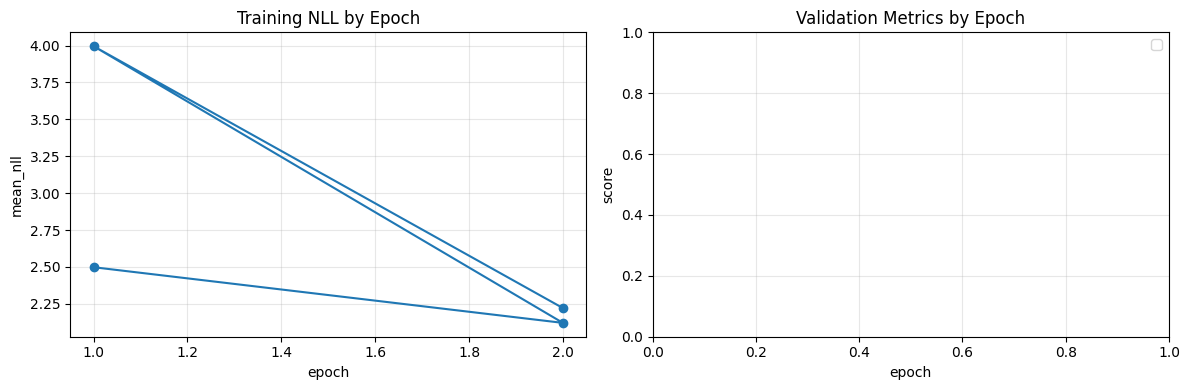

Final model checkpoint: /content/drive/MyDrive/facialgen_checkpoints/coraml_t4_run/final


In [ ]:
history_df = pd.DataFrame(history)
display(history_df)
if not history_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['epoch'], history_df['mean_nll'], marker='o', label='train NLL')
    axes[0].set_title('Training NLL by Epoch')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('mean_nll')
    axes[0].grid(True, alpha=0.3)
    if 'val_roc_auc' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_roc_auc'], marker='o', label='val ROC-AUC')
    if 'val_ap' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_ap'], marker='o', label='val AP')
    if 'val_score' in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df['val_score'], marker='o', label='val score')
    axes[1].set_title('Validation Metrics by Epoch')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('score')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

print('Final model checkpoint:', Path(args.save_dir) / 'final' if args.save_dir else 'not saved')


## Final Evaluation

Generate walks from the trained model, reconstruct a graph, and compare link prediction and graph statistics against the true CoraML LCC.


In [ ]:
reference_adj = eval_info['reference_adj']
overlap_adj = eval_info.get('overlap_adj', reference_adj)
overlap_name = str(eval_info.get('overlap_name', 'reference'))
reference_labels = eval_info['reference_labels']
num_nodes = int(eval_info['num_nodes'])
num_reference_edges = int(eval_info['num_reference_edges'])
if final_max_length is None:
    final_max_length = (
        train_mod.default_face_generation_max_length(args.vertex_context_size)
        if args.walk_type in {'facial', 'facial_online'}
        else train_mod.default_random_walk_generation_max_length(args.vertex_context_size)
    )
print(f'final generation max_length = {final_max_length}')
lp_split = eval_info['link_prediction_split']
if lp_split is None:
    lp_split = connected_link_prediction_split(
        reference_adj,
        val_fraction=args.val_fraction,
        test_fraction=args.test_fraction,
        seed=args.split_seed,
    )

reference_stats = compute_graph_statistics(reference_adj, labels=reference_labels)

generated_results = []
generated_stats_rows = []

for graph_idx in range(num_generated_graphs):
    walks = sample_model_walks(
        model,
        num_samples=final_generated_walks,
        max_length=final_max_length,
        bos_token_id=int(eval_info['bos_token_id']),
        device=device,
        walk_type=str(eval_info.get('walk_type', args.walk_type)),
        batch_size=generation_batch_size,
        show_progress=True,
        progress_desc=f'final sampling graph {graph_idx + 1}/{num_generated_graphs}',
    )

    A_hat, S = reconstruct_graph_from_generated_walks(
        walks,
        num_nodes=num_nodes,
        target_num_edges=num_reference_edges,
        seed=reconstruction_seed + graph_idx,
        walk_type=str(eval_info.get('walk_type', args.walk_type)),
        score_symmetrization=eval_info.get('score_symmetrization', args.score_symmetrization),
    )

    val_scores = link_prediction_scores_from_walks(
        walks,
        num_nodes=num_nodes,
        positive_edges=lp_split['val_edges'],
        negative_edges=lp_split['val_non_edges'],
        walk_type=str(eval_info.get('walk_type', args.walk_type)),
        score_symmetrization=eval_info.get('score_symmetrization', args.score_symmetrization),
    )
    test_scores = link_prediction_scores_from_walks(
        walks,
        num_nodes=num_nodes,
        positive_edges=lp_split['test_edges'],
        negative_edges=lp_split['test_non_edges'],
        walk_type=str(eval_info.get('walk_type', args.walk_type)),
        score_symmetrization=eval_info.get('score_symmetrization', args.score_symmetrization),
    )
    graph_stats = compute_graph_statistics(A_hat, labels=reference_labels)
    overlap = edge_overlap_ratio(A_hat, overlap_adj)

    generated_results.append({
        'graph_id': graph_idx,
        'val_roc_auc': float(val_scores['roc_auc']),
        'val_ap': float(val_scores['average_precision']),
        'test_roc_auc': float(test_scores['roc_auc']),
        'test_ap': float(test_scores['average_precision']),
        f'edge_overlap[{overlap_name}]': float(overlap),
    })
    generated_stats_rows.append(graph_stats)

lp_table = pd.DataFrame(generated_results)
display(lp_table)

metric_names = list(reference_stats.keys())
stats_table = pd.DataFrame([
    {
        'metric': metric,
        'true_coraml': float(reference_stats[metric]),
        'generated_mean': float(np.nanmean([row[metric] for row in generated_stats_rows])),
        'abs_diff': abs(
            float(np.nanmean([row[metric] for row in generated_stats_rows]))
            - float(reference_stats[metric])
        ),
    }
    for metric in metric_names
])
display(stats_table)

if history:
    history_df = pd.DataFrame(history)
    display(history_df)

    generated_stat_cols = [
        col for col in history_df.columns
        if col.startswith('generated_')
    ]
    if generated_stat_cols:
        generated_stats_history = history_df[['epoch', *generated_stat_cols]].copy()
        display(generated_stats_history)

        plot_cols = [
            col for col in generated_stat_cols
            if pd.api.types.is_numeric_dtype(history_df[col])
        ]
        if plot_cols:
            fig, axes = plt.subplots(
                len(plot_cols),
                1,
                figsize=(10, max(3, 2.5 * len(plot_cols))),
                sharex=True,
            )
            axes = np.atleast_1d(axes)
            for ax, col in zip(axes, plot_cols):
                ax.plot(history_df['epoch'], history_df[col], marker='o')
                ax.set_title(col)
                ax.set_ylabel(col.replace('generated_', ''))
                ax.grid(alpha=0.3)
            axes[-1].set_xlabel('epoch')
            plt.tight_layout()
            plt.show()


final generation max_length = 17


final sampling graph 1/1:   0%|          | 0/100000 [00:00<?, ?walk/s]

KeyboardInterrupt: 